In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("Steel_industry_data.csv", encoding="utf-8")
# print(df.describe())
print(df.info())
nan_amount = df.isnull().sum()
# print(nan_amount)
print(df.columns)
df = df.dropna()
# print(df.info())
# print(type(df["date"]))
print(df["date"].head(5))
# print(df["date"].tail(5))

df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M", dayfirst=True)
df["month_num"] = df["date"].dt.month.astype("Int64")

map_month = df["month_num"].replace(12, 0)
df["season"] = pd.cut(map_month, bins=[-1, 2, 5, 8, 11], labels=[1, 2, 3, 4])

print(df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [3]:
total_per_season = df.groupby("season")["Usage_kWh"].sum().reset_index()
print(total_per_season)

  season  Usage_kWh
0      1  277172.41
1      2  238059.49
2      3  215638.48
3      4  228766.33


C:\Users\0\AppData\Local\Temp\ipykernel_11752\16881980.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_per_season = df.groupby("season")["Usage_kWh"].sum().reset_index()


C:\Users\0\AppData\Local\Temp\ipykernel_11752\107305189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_per_season, x="season", y="Usage_kWh", palette="viridis")


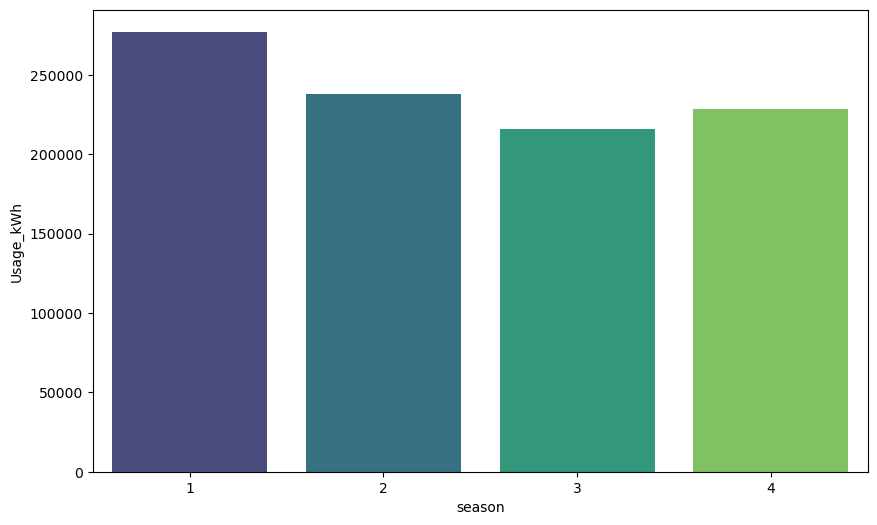

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=total_per_season, x="season", y="Usage_kWh", palette="viridis")
plt.xlabel("season")
plt.ylabel("Usage_kWh")
plt.show()

In [5]:
chi2, p_value, dof, expected = stats.chi2_contingency(total_per_season)
print(chi2)
print(p_value)
print(dof)  # число степеней свободы
print(expected)  # ожидаемая матрица
print(total_per_season)

2.675551322034176
0.4443980928050132
3
[[2.88828594e+00 2.77170522e+05]
 [2.48072012e+00 2.38059009e+05]
 [2.24709237e+00 2.15639233e+05]
 [2.38390157e+00 2.28767946e+05]]
  season  Usage_kWh
0      1  277172.41
1      2  238059.49
2      3  215638.48
3      4  228766.33


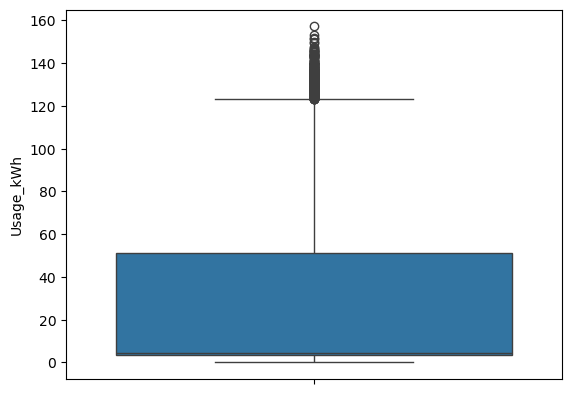

In [6]:
sns.boxplot(df["Usage_kWh"])
plt.show()


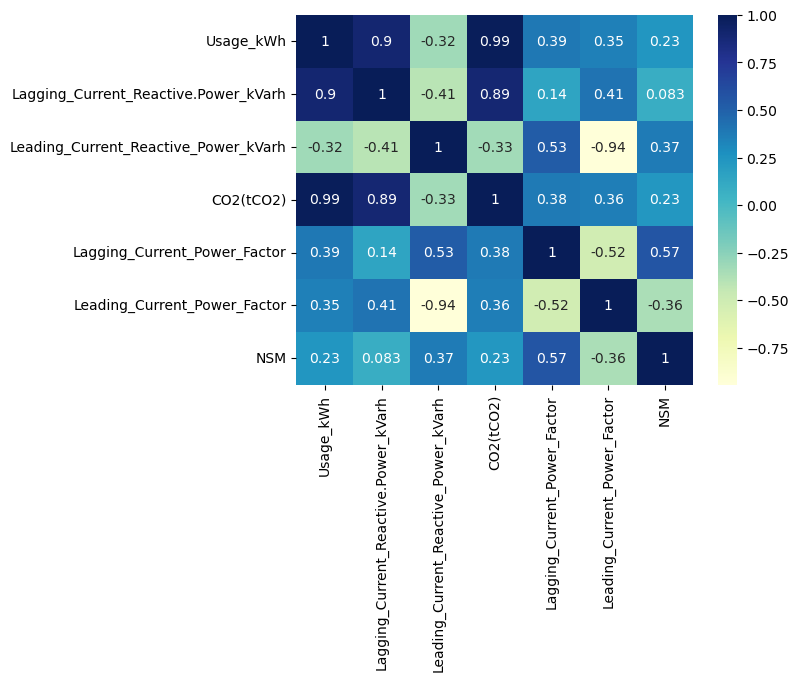

'\ndate                                  35040 non-null  object \n 1   Usage_kWh                             35040 non-null  float64\n 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64\n 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64\n 4   CO2(tCO2)                             35040 non-null  float64\n 5   Lagging_Current_Power_Factor          35040 non-null  float64\n 6   Leading_Current_Power_Factor          35040 non-null  float64\n 7   NSM                                   35040 non-null  int64  \n 8   WeekStatus                            35040 non-null  object \n 9   Day_of_week                           35040 non-null  object \n 10  Load_Type                             35040 non-null  object \n\n'

In [7]:
numeric_features = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM",
]
pearson_matrix = df[numeric_features].corr()
sns.heatmap(pearson_matrix, annot=True, cmap="YlGnBu")
plt.show()

"""
date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 

"""

In [8]:
def IQR_clean(df, column):
    Q_1 = df[column].quantile(0.25)
    Q_3 = df[column].quantile(0.75)

    IQR = Q_3 - Q_1
    lower_bound = Q_1 - 1.5 * IQR
    upper_bound = Q_3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(
        f"Выбросы в {column}: {len(outliers)} ({len(outliers) / len(df[column]) * 100:.2f}%)"
    )

    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df


In [9]:
for col in numeric_features:
    df = IQR_clean(df, col)

Выбросы в Usage_kWh: 328 (0.94%)
Выбросы в Lagging_Current_Reactive.Power_kVarh: 1059 (3.02%)
Выбросы в Leading_Current_Reactive_Power_kVarh: 7759 (22.14%)
Выбросы в CO2(tCO2): 437 (1.25%)
Выбросы в Lagging_Current_Power_Factor: 1 (0.00%)
Выбросы в Leading_Current_Power_Factor: 8327 (23.76%)
Выбросы в NSM: 0 (0.00%)


In [ ]:
df_enc = df.copy()
df_enc["date"] = pd.to_datetime(df_enc["date"], format="%d/%m/%Y %H:%M")
df_enc["hour"] = df_enc["date"].dt.hour
df_enc["energy_efficiency"] = df_enc["Usage_kWh"] / df_enc["CO2(tCO2)"]
df_enc["is_peak"] = (df_enc["hour"] >= 8) & (df_enc["hour"] <= 20).astype(int)

In [ ]:
new_numeric_features = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "hour",
    "energy_efficiency",
    "is_peak",
]

target = "Usage_kWh"
x = df_enc[new_numeric_features]
y = df_enc[target]

corr_target = x.corrwith(y).abs().sort_values(ascending=False)
top_features = corr_target.head(10).index.tolist()

